 Loading data from: /Users/li0o0sun/projects/Projectwork2026/data/09_filtered_all_data.pkl ...
 Pre-filter shape: (1488351, 162)
 Post-filter shape (Only 'walk'): (365925, 162)
 Segmenting signals and targeting G_DA_X...
 Extracted X shape: (3658, 48), y shape: (3658,)
 Training ANN Regressor...

 Regression Performance:
Target Axis -> RMSE: 0.99 degrees | R-squared: 0.4535


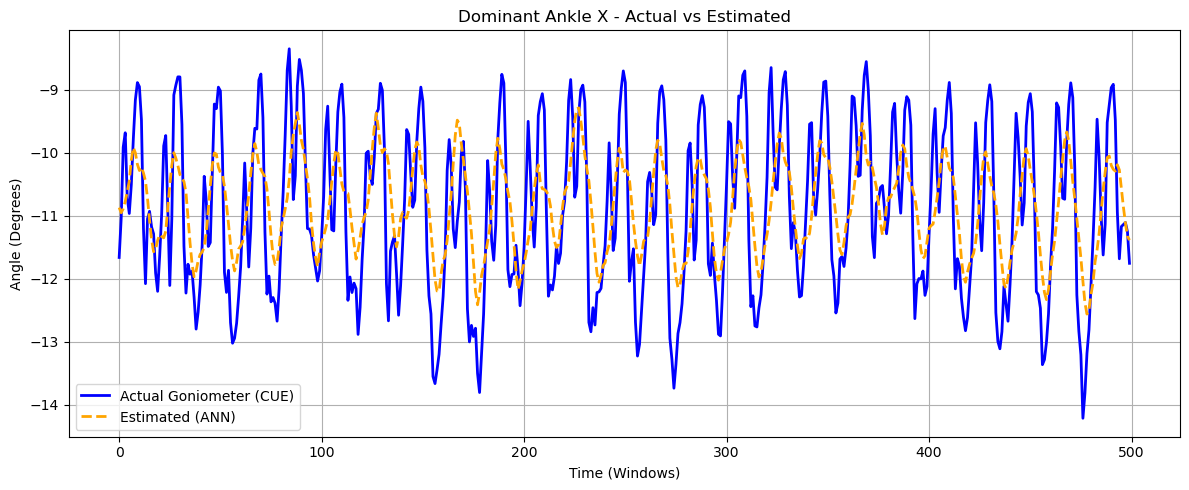

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# ==========================================
# ZONE 1: DATA MANAGEMENT
# ==========================================
def load_and_filter_data(filepath, target_activity):
    """Loads the pickle file and filters down strictly to the target activity."""
    print(f" Loading data from: {filepath} ...")
    df = pd.read_pickle(filepath)

    float_cols = df.select_dtypes(include=['float64']).columns
    df[float_cols] = df[float_cols].astype('float32')

    print(f" Pre-filter shape: {df.shape}")
    # Filter for single activity (e.g., 'walk')
    df = df[df['Activity'] == target_activity].copy()
    df.reset_index(drop=True, inplace=True)
    print(f" Post-filter shape (Only '{target_activity}'): {df.shape}")

    return df

# ==========================================
# ZONE 2: REGRESSION PIPELINE (ANN)
# ==========================================
class BiosignalRegressor:
    def __init__(self, window_size=200, overlap=100):
        self.window_size = window_size
        self.overlap = overlap
        self.step_size = window_size - overlap
        
        self.scaler = StandardScaler()
        # Replicating MATLAB's feedforwardnet(20)
        self.ann_model = MLPRegressor(
            hidden_layer_sizes=(20,), 
            activation='relu',
            solver='adam',
            max_iter=500,
            early_stopping=True,
            random_state=42
        )

    def segment_and_extract(self, df, target_col_name='G_DA_X'):
        """Extracts EMG/IMU as inputs (X) and a SINGLE Goniometer axis as target (y)."""
        print(f" Segmenting signals and targeting {target_col_name}...")
        
        emg_cols = [c for c in df.columns if 'EMG_TA_Pool' in c or 'EMG_GM_Pool' in c]
        imu_cols = [c for c in df.columns if c.endswith('-f') or c.endswith('-c') or c.endswith('-q') or c.endswith('-h')]
        
        #  Find the exact index of our target column
        gonio_cols = [c for c in df.columns if c.startswith('G_')]
        target_idx = gonio_cols.index(target_col_name)
        
        X_features, y_targets = [], []
        
        emg_data = df[emg_cols].to_numpy(dtype=np.float32)
        imu_data = df[imu_cols].to_numpy(dtype=np.float32)
        gonio_data = df[gonio_cols].to_numpy(dtype=np.float32)
        
        for start_idx in range(0, len(df) - self.window_size, self.step_size):
            end_idx = start_idx + self.window_size
            window_features = []
            
            # --- INPUTS (X): EMG & IMU ---
            w_emg = emg_data[start_idx:end_idx]
            
            window_features.extend(np.sqrt(np.mean(w_emg**2, axis=0)))
            window_features.extend(np.mean(np.abs(w_emg), axis=0))
            window_features.extend(np.sum(np.abs(np.diff(w_emg, axis=0)), axis=0))
            window_features.extend(np.sum((w_emg[:-1] * w_emg[1:]) < 0, axis=0))
            
            diffs = np.diff(w_emg, axis=0)
            ssc = np.sum((diffs[:-1] * diffs[1:]) < 0, axis=0)
            window_features.extend(ssc)
            
            w_imu = imu_data[start_idx:end_idx]
            window_features.extend(np.mean(w_imu, axis=0))
            window_features.extend(np.sqrt(np.mean(w_imu**2, axis=0)))
            
            X_features.append(window_features)
            
            # --- TARGET (y): Single Goniometer Axis ---
            #  Only extract the mean of the specific target axis
            w_gonio = gonio_data[start_idx:end_idx, target_idx]
            y_targets.append(np.mean(w_gonio))
            
        return np.nan_to_num(np.array(X_features)), np.array(y_targets)

    def train_model(self, X_train, y_train):
        X_train_scaled = self.scaler.fit_transform(X_train)
        self.ann_model.fit(X_train_scaled, y_train)
        return self.ann_model, self.scaler

# ==========================================
# ZONE 3: POST-PROCESSING & VISUALIZATION
# ==========================================
def smooth_predictions(predictions, window=10):
    """Replicates the MATLAB Moving Average (MA) filter using Pandas rolling mean."""
    df_preds = pd.DataFrame(predictions)
    # Applying a centered moving average
    smoothed = df_preds.rolling(window=window, center=True, min_periods=1).mean()
    return smoothed.to_numpy()

def plot_kinematics(y_true, y_pred_smoothed, title="Actual vs Estimated Kinematics"):
    """Plots the continuous estimated angle vs the actual cue."""
    plt.figure(figsize=(12, 5))
    
    plt.plot(y_true[:500], label='Actual Goniometer (CUE)', color='blue', linewidth=2)
    plt.plot(y_pred_smoothed[:500], label='Estimated (ANN)', color='orange', linestyle='dashed', linewidth=2)
    
    plt.title(title)
    plt.xlabel('Time (Windows)')
    plt.ylabel('Angle (Degrees)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ==========================================
# ZONE 4: MAIN EXECUTION CONTROLLER
# ==========================================
if __name__ == "__main__":
    BASE_PATH = "/Users/li0o0sun/projects/Projectwork2026/data"
    FILE_NAME = "09_filtered_all_data.pkl"
    
    # 1. Load strictly "walk" data
    df = load_and_filter_data(os.path.join(BASE_PATH, FILE_NAME), target_activity='walk')
    
    if df is not None:
        # 2. Segment and Extract
        regressor_pipeline = BiosignalRegressor(window_size=200, overlap=100)
        # X, y = regressor_pipeline.segment_and_extract(df)
        X, y = regressor_pipeline.segment_and_extract(df, target_col_name='G_DA_X')
        print(f" Extracted X shape: {X.shape}, y shape: {y.shape}")
        
        # 3. Train/Test Split (Sequential split to preserve time-series nature)
        split_idx = int(len(X) * 0.8)
        X_train, X_test = X[:split_idx], X[split_idx:]
        y_train, y_test = y[:split_idx], y[split_idx:]
        
        # 4. Train ANN
        print(" Training ANN Regressor...")
        model, scaler = regressor_pipeline.train_model(X_train, y_train)
        
        # 5. Predict and Smooth
        X_test_scaled = scaler.transform(X_test)
        y_pred = model.predict(X_test_scaled)
        
        # Apply the Moving Average filter (similar to MATLAB's conv(estimated, MA))
        y_pred_smoothed = smooth_predictions(y_pred, window=10)
        
        # 6. Calculate Performance Metrics
        print("\n Regression Performance:")
        # We calculate metrics for the first Goniometer axis as an example
        rmse = np.sqrt(mean_squared_error(y_test, y_pred_smoothed))
        r2 = r2_score(y_test, y_pred_smoothed)
        print(f"Target Axis -> RMSE: {rmse:.2f} degrees | R-squared: {r2:.4f}")
        
        # 7. Visualize
        plot_kinematics(y_test, y_pred_smoothed, title="Dominant Ankle X - Actual vs Estimated")